# TP2 Starter Pack: Image-to-Prompt Inversion

This notebook provides the basic utilities needed for TP2:

- mount Google Drive in Colab / VS Code Colab extension;
- load the TP2 target images;
- extract the fixed render seed from each target filename;
- load the LCM generator `SimianLuo/LCM_Dreamshaper_v7`;
- generate images from prompts using the same settings as the target images;
- save generated images and metadata.

The goal of TP2 is to find prompts that reproduce the target images as closely as possible when rendered with the same LCM setup.


## 1. Install Dependencies

For local runs, create and activate a clean conda environment first, then install the dependencies in this order:

```powershell
conda create -n GEN_AI_TP2 python=3.11 -y
conda activate GEN_AI_TP2
conda install pytorch pytorch-cuda=12.1 -c pytorch -c nvidia -y
python -m pip install "sympy==1.13.1"
python -m pip install "diffusers==0.35.2" "transformers<5" accelerate safetensors matplotlib torchvision==0.20.1 ipywidgets "pandas<3" "Pillow<12" numpy
```

Then select that conda environment as the notebook kernel and run the cells below.

For **Colab**: uses the default Colab runtime Python.

The notebook installer cell is only a fallback/check for missing Python packages.


In [1]:
# Safe installer for local runs. Set SKIP_INSTALL = True to skip installation.
# This cell assumes the conda environment was already created, activated, and has CUDA-enabled PyTorch installed.
SKIP_INSTALL = globals().get("SKIP_INSTALL", True)
if SKIP_INSTALL:
    print('SKIP_INSTALL=True — skipping package installation')
else:
    import importlib, subprocess, sys

    def ensure(pkg):
        name = pkg.split('[')[0].split('<')[0].split('==')[0]
        try:
            importlib.import_module(name)
            return False
        except Exception:
            subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg])
            return True

    pkgs = [
        "numpy",
        "sympy==1.13.1",
        "diffusers==0.35.2",
        "transformers<5",
        "accelerate",
        "safetensors",
        "matplotlib",
        "torchvision==0.20.1",
        "ipywidgets",
        "pandas<3",
        "Pillow<12",
    ]

    installed_any = False
    for p in pkgs:
        try:
            installed_any |= ensure(p)
        except Exception as e:
            print('Failed to install', p, ':', e)

    if installed_any:
        print('Installed missing packages — restart the kernel before heavy imports.')
    else:
        print('All required packages already installed.')


SKIP_INSTALL=True — skipping package installation


In [2]:
import sys
import torch
print(sys.executable)
print(torch.__version__)
print(getattr(torch.version,'cuda',None))
print(torch.cuda.is_available())
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

w:\miniconda\envs\GEN_AI_TP2\python.exe
2.5.1
12.1
True
Using device: cuda


## 2. Google Drive and Target Paths

The notebook avoids the Colab upload widget, which is unreliable in the VS Code Colab extension.

Recommended Drive layout:

```text
MyDrive/GENAI_TP2/tp2-chosen/*.png
```

Alternative: place `tp2-chosen.zip` in `MyDrive/GENAI_TP2/`.


In [3]:
from pathlib import Path
import zipfile
import urllib.request

# Default to local execution. Set True if you want to mount Google Drive (Colab).
MOUNT_GOOGLE_DRIVE = False

if MOUNT_GOOGLE_DRIVE:
    try:
        from google.colab import drive
        drive.mount("/content/drive", force_remount=False)
    except Exception as exc:
        print("Google Drive mount skipped:", exc)

# Optional online URL for a zip with the target images.
TARGETS_ZIP_URL = ""

CONTENT_DIR = Path("/content")
DRIVE_ROOT = Path("/content/drive/MyDrive")
DRIVE_PROJECT_DIR = DRIVE_ROOT / "GENAI_TP2"
LOCAL_PROJECT_DIR = CONTENT_DIR / "GENAI_TP2" if CONTENT_DIR.exists() else Path("students")

# Output dir: prefer local project outputs unless mounting Drive
if DRIVE_ROOT.exists() and MOUNT_GOOGLE_DRIVE:
    DRIVE_PROJECT_DIR.mkdir(parents=True, exist_ok=True)
    OUTPUT_DIR = DRIVE_PROJECT_DIR / "outputs"
elif CONTENT_DIR.exists():
    OUTPUT_DIR = CONTENT_DIR / "tp2_outputs"
else:
    OUTPUT_DIR = Path("students/outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

IMAGE_EXTENSIONS = {".png", ".jpg", ".jpeg", ".webp", ".bmp"}

def list_target_images(path):
    path = Path(path)
    if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS:
        return [path]
    if not path.exists():
        return []
    return sorted(p for p in path.rglob("*") if p.suffix.lower() in IMAGE_EXTENSIONS)

# Prefer project-local folders first
TARGET_DIR_CANDIDATES = [
    Path("tp2-chosen"),
    Path("students/tp2-chosen"),
    Path("/content/tp2-chosen"),
    Path("/content/tp2_targets"),
]
if MOUNT_GOOGLE_DRIVE:
    TARGET_DIR_CANDIDATES += [
        DRIVE_PROJECT_DIR / "tp2-chosen",
        Path("/content/drive/MyDrive/tp2-chosen"),
        Path("/content/drive/MyDrive/tp2_targets"),
    ]

ZIP_CANDIDATES = [
    Path("tp2-chosen.zip"),
    Path("students/tp2-chosen.zip"),
    Path("/content/tp2-chosen.zip"),
]
if MOUNT_GOOGLE_DRIVE:
    ZIP_CANDIDATES += [DRIVE_PROJECT_DIR / "tp2-chosen.zip", Path("/content/drive/MyDrive/tp2-chosen.zip")]

# Download optional online zip.
if TARGETS_ZIP_URL:
    LOCAL_PROJECT_DIR.mkdir(parents=True, exist_ok=True)
    downloaded_zip = LOCAL_PROJECT_DIR / "tp2-chosen.zip"
    urllib.request.urlretrieve(TARGETS_ZIP_URL, downloaded_zip)
    ZIP_CANDIDATES.insert(0, downloaded_zip)
    print("Downloaded targets zip to", downloaded_zip)

# Extract first available zip if no folder with images exists yet.
if not any(list_target_images(candidate) for candidate in TARGET_DIR_CANDIDATES):
    for zip_path in ZIP_CANDIDATES:
        if zip_path.exists():
            extract_dir = Path("/content/tp2-chosen") if CONTENT_DIR.exists() else Path("tp2-chosen")
            extract_dir.mkdir(parents=True, exist_ok=True)
            with zipfile.ZipFile(zip_path) as zf:
                zf.extractall(extract_dir)
            print(f"Extracted {zip_path} -> {extract_dir}")
            break

TARGET_DIR = None
for candidate in TARGET_DIR_CANDIDATES:
    if list_target_images(candidate):
        TARGET_DIR = candidate
        break

if TARGET_DIR is None:
    raise FileNotFoundError(
        "No target images found. Put images in tp2-chosen/ (project root) or students/tp2-chosen/, "
        "or put tp2-chosen.zip in the project root, or set TARGETS_ZIP_URL."
    )

target_images = list_target_images(TARGET_DIR)
print("Target folder:", TARGET_DIR)
print("Output folder:", OUTPUT_DIR)
print("Number of targets:", len(target_images))
target_images


Target folder: tp2-chosen
Output folder: students\outputs
Number of targets: 6


[WindowsPath('tp2-chosen/1159_25.png'),
 WindowsPath('tp2-chosen/1159_29.png'),
 WindowsPath('tp2-chosen/1159_3.png'),
 WindowsPath('tp2-chosen/1159_7.png'),
 WindowsPath('tp2-chosen/7836.png'),
 WindowsPath('tp2-chosen/9338.png')]

## 3. Utilities: Seeds, Display, and Output Folders

The target filename encodes the render seed:

- `7836.png` uses seed `7836`;
- `1159_25.png` uses seed `1159`.


In [5]:
import csv
import json
import re
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
from IPython.display import display
from PIL import Image


def seed_from_filename(path, fallback=2026):
    match = re.match(r"^(\d+)", Path(path).stem)
    return int(match.group(1)) if match else fallback


def safe_stem(path):
    return "".join(ch if ch.isalnum() or ch in ("-", "_") else "_" for ch in Path(path).stem)


def load_image(path):
    return Image.open(path).convert("RGB")


def create_run_dir(base_dir=OUTPUT_DIR, identity="student_run"):
    timestamp = datetime.now().strftime("%Y%m%d-%H%M%S")
    run_dir = Path(base_dir) / f"{timestamp}_{identity}"
    run_dir.mkdir(parents=True, exist_ok=False)
    return run_dir


def write_csv(path, rows):
    rows = list(rows)
    Path(path).parent.mkdir(parents=True, exist_ok=True)
    if not rows:
        Path(path).write_text("")
        return
    fieldnames = []
    for row in rows:
        for key in row.keys():
            if key not in fieldnames:
                fieldnames.append(key)
    with open(path, "w", newline="") as handle:
        writer = csv.DictWriter(handle, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(rows)


def show_images(paths, cols=3, title=None):
    paths = list(paths)
    if not paths:
        print("No images to show.")
        return
    rows = (len(paths) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
    if rows == 1 and cols == 1:
        axes = [[axes]]
    elif rows == 1:
        axes = [axes]
    elif cols == 1:
        axes = [[ax] for ax in axes]
    for ax in [ax for row in axes for ax in row]:
        ax.axis("off")
    for ax, path in zip([ax for row in axes for ax in row], paths):
        ax.imshow(load_image(path))
        ax.set_title(Path(path).name)
        ax.axis("off")
    if title:
        fig.suptitle(title)
    plt.tight_layout()
    plt.show()


for path in target_images:
    print(Path(path).name, "-> seed", seed_from_filename(path))


1159_25.png -> seed 1159
1159_29.png -> seed 1159
1159_3.png -> seed 1159
1159_7.png -> seed 1159
7836.png -> seed 7836
9338.png -> seed 9338


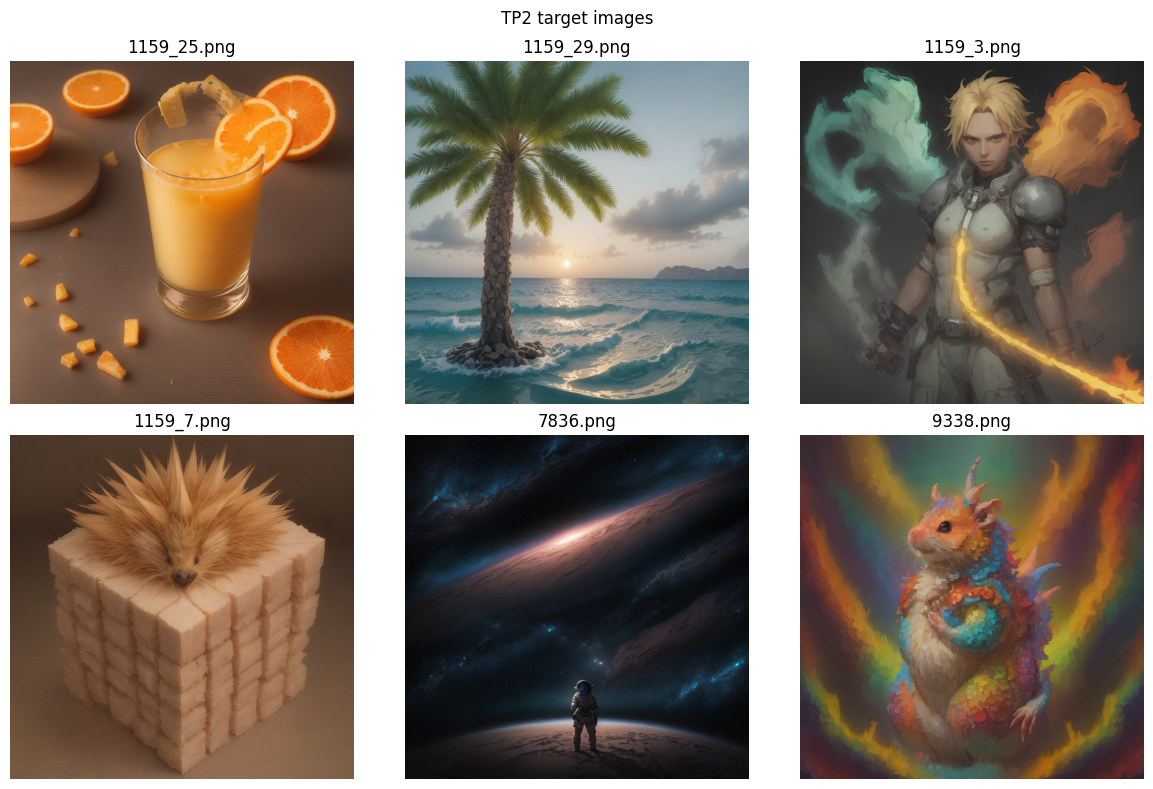

In [6]:
show_images(target_images, cols=3, title="TP2 target images")


## 4. Load the LCM Generator

These are the fixed generation settings used for TP2 targets.

In [ ]:
from dataclasses import dataclass
import torch
from diffusers import DiffusionPipeline, LCMScheduler


@dataclass(frozen=True)
class LCMConfig:
    model_id: str = "SimianLuo/LCM_Dreamshaper_v7"
    seed: int = 2026  # fallback only; target filenames define the real render seed
    num_inference_steps: int = 8
    guidance_scale: float = 8.0
    lcm_origin_steps: int = 50
    width: int = 768
    height: int = 768


config = LCMConfig()


def default_device():
    if torch.cuda.is_available():
        return "cuda"
    if getattr(torch.backends, "mps", None) and torch.backends.mps.is_available():
        return "mps"
    return "cpu"


device = default_device()
print("Using device:", device)


def load_lcm_pipeline(config):
    dtype = torch.float32
    pipe = DiffusionPipeline.from_pretrained(
        config.model_id,
        torch_dtype=dtype,
        use_safetensors=True,
    )
    pipe.scheduler = LCMScheduler.from_config(pipe.scheduler.config)
    if hasattr(pipe, "safety_checker"):
        pipe.safety_checker = None
    pipe.to(device)
    return pipe


pipe = load_lcm_pipeline(config)


## 5. Generate and Save Images

Use `render_prompt_for_target(...)` to render a prompt with the seed encoded in the target filename.

In [ ]:
import numpy as np
from PIL import Image

def _normalize_generated_image(image_array):
    image_array = np.asarray(image_array, dtype=np.float32)
    image_array = np.nan_to_num(image_array, nan=0.0, posinf=1.0, neginf=0.0)
    min_value = float(image_array.min()) if image_array.size else 0.0
    max_value = float(image_array.max()) if image_array.size else 0.0
    if min_value < 0.0 or max_value > 1.0:
        if min_value >= -1.0 and max_value <= 1.0:
            image_array = (image_array + 1.0) / 2.0
        else:
            spread = max_value - min_value
            if spread > 1e-8:
                image_array = (image_array - min_value) / spread
            else:
                image_array = np.zeros_like(image_array)
    image_array = np.clip(image_array, 0.0, 1.0)
    return image_array, min_value, max_value

def render_prompt(prompt, seed, pipe=pipe, config=config):
    generator_device = "cpu" if device == "mps" else device
    generator = torch.Generator(device=generator_device).manual_seed(seed)
    result = pipe(
        prompt=prompt,
        num_inference_steps=config.num_inference_steps,
        guidance_scale=config.guidance_scale,
        lcm_origin_steps=config.lcm_origin_steps,
        width=config.width,
        height=config.height,
        output_type="np",
        generator=generator,
    )
    raw_image = result.images[0]
    print("generated raw type:", type(raw_image), "dtype:", getattr(raw_image, "dtype", None), "shape:", getattr(raw_image, "shape", None))
    image_array, min_value, max_value = _normalize_generated_image(raw_image)
    nonzero_count = int(np.count_nonzero(image_array))
    mean_value = float(image_array.mean()) if image_array.size else 0.0
    print(f"generated image range: min={min_value:.8e}, max={max_value:.8e}, mean={mean_value:.8e}, nonzero={nonzero_count}")
    image_array = (image_array * 255.0).round().astype(np.uint8)
    return Image.fromarray(image_array)


def render_prompt_for_target(prompt, target_path):
    seed = seed_from_filename(target_path, config.seed)
    return render_prompt(prompt, seed=seed)


def save_generated_image(image, run_dir, target_path, prompt_index=1):
    target_dir = Path(run_dir) / safe_stem(target_path)
    target_dir.mkdir(parents=True, exist_ok=True)
    path = target_dir / f"candidate_{prompt_index:03d}.png"
    image.save(path)
    return path


## 6. Minimal Example

Change `example_prompt` and `target_path` to test your own prompts.

In [ ]:
from dataclasses import replace

run_dir = create_run_dir(identity="starter_example")

target_path = next(path for path in target_images if Path(path).name == "1159_25.png")
example_prompt = "orange juice"

# Conservative diagnostic run: fewer steps and lower guidance to see whether the model still collapses to zero.
test_config = replace(config, num_inference_steps=4, guidance_scale=1.0, width=512, height=512)

generated = render_prompt(example_prompt, seed=seed_from_filename(target_path), config=test_config)
saved_path = save_generated_image(generated, run_dir, target_path, prompt_index=1)

print("Target:", target_path)
print("Seed:", seed_from_filename(target_path))
print("Prompt:", example_prompt)
print("Saved generated image:", saved_path)

display(generated)


## 7. Batch Template for Student Prompts

Fill `candidate_prompts` with your recovered prompts. The keys must be target filenames.

In [ ]:
candidate_prompts = {
    "1159_25.png": [
        "Orange Juice",
    ],
}

run_dir = create_run_dir(identity="student_prompts")
rows = []

target_by_name = {Path(path).name: path for path in target_images}
for image_name, prompts in candidate_prompts.items():
    target_path = target_by_name.get(image_name)
    if target_path is None:
        print("Skipping unknown target:", image_name)
        continue
    seed = seed_from_filename(target_path, config.seed)
    for index, prompt in enumerate(prompts, start=1):
        generated = render_prompt(prompt, seed=seed)
        image_path = save_generated_image(generated, run_dir, target_path, prompt_index=index)
        rows.append({
            "target": str(target_path),
            "target_name": image_name,
            "render_seed": seed,
            "candidate_index": index,
            "prompt": prompt,
            "render": str(image_path),
        })

write_csv(run_dir / "generated_prompts.csv", rows)
(run_dir / "generated_prompts.json").write_text(json.dumps(rows, indent=2, ensure_ascii=False))
print("Saved run to:", run_dir)
print("Generated", len(rows), "image(s)")


## 8. View Generated Outputs

In [ ]:
generated_paths = [row["render"] for row in rows]
show_images(generated_paths, cols=3, title="Generated candidates")


## 9. What To Do Next?

Read the full project statement in `GenAI-TP2.pdf` before starting the actual work. This notebook only gives the basic infrastructure for loading targets, controlling seeds, rendering prompts with the fixed LCM setup, and saving outputs.

For the project itself, you still need to design your own method for choosing candidate prompts, run it for every target image, keep the three best prompts per target, save the corresponding generated images, and report the results according to the evaluation protocol in the statement.

In addition to the approach used to obtain good prompts, you must also handle evaluation carefully. The mandatory metrics are:

- CLIP image-image similarity between the target image and the generated image;
- LPIPS perceptual distance between the target image and the generated image;
- Pixel MSE

The report should include the top-3 prompts and generated images for each target, plus the metric values used to justify the ranking.


## 10. Implementation

### Vision-language captioning + ?

#### Vision-language captioning using BLIP and CLIP:
1. Using BLIP do generate x captions by target (with a BLIP model, in this case Salesforce/blip-image-captioning-large) 
2. Expanding each caption into 4-8 prompts with templates (style, ambience light, lens, ...)
3. Using CLIP (in this case, model openai/clip-vit-large-patch14) to embed and rank images.

#### ?:

## BLIP
#### Converts image to text by generating a natural descriptions of the image. 

In [7]:
# Generate x captions per image using BLIP
# TIRAR DEPOIS: SE MUITO PESADO TENTAR PROCURAR VERSAO BASE

BLIP_MODEL = "Salesforce/blip-image-captioning-large"

def generate_captions_for_image(target_path, model_name=BLIP_MODEL, num_captions=3, device=device, max_length=40, temperature=1.0, top_k=50, top_p=0.95):
    """Return a list of textual captions for the input image using BLIP."""
    print("Loaded BLIP model for captioning:", BLIP_MODEL, "on device:", device)
    from transformers import BlipProcessor, BlipForConditionalGeneration

    processor = BlipProcessor.from_pretrained(model_name, use_fast=False)
    #processor = BlipProcessor.from_pretrained(model_name)
    model = BlipForConditionalGeneration.from_pretrained(model_name).to("cuda")

    image = load_image(target_path)
    inputs = processor(images=image, return_tensors="pt").to(device)

    # do_sample=True enables sampling-based generation, which allows for more diverse captions compared to greedy decoding.
    # top_k is the number of highest-probability vocabulary tokens to keep for top-k-filtering
    # top_p is the cumulative probability for nucleus sampling; tokens are sorted by probability and added until the sum of probabilities exceeds top_p
    # temperature controls randomness in sampling: higher values lead to more random outputs, while lower values make the model more deterministic.
    # num_return_sequences is the number of captions to generate for the same image, which can be useful for diversity.
    # max_length limits the length of the generated captions to prevent excessively long outputs.
    outputs = model.generate(
        **inputs,
        do_sample=True,
        top_k=top_k,
        top_p=top_p,
        temperature=temperature,
        num_return_sequences=num_captions,
        max_length=max_length,
    )

    tokenizer = processor.tokenizer
    captions = [tokenizer.decode(o, skip_special_tokens=True).strip() for o in outputs]
    return captions

print("Generated captions for target images:")
for target_path in target_images:
    captions = generate_captions_for_image(target_path, num_captions=3)
    print(f"{Path(target_path).name} original captions:")
    for caption in captions:
        print("  -", caption)


Generated captions for target images:
Loaded BLIP model for captioning: Salesforce/blip-image-captioning-large on device: cuda
1159_25.png original captions:
  - peeled orange slices lie in pieces next to a glass of juice
  - dimly lit orange juice garnished by a wedge of crumbs on the table
  - grove orange juice and cubes of sugar are arranged on a table
Loaded BLIP model for captioning: Salesforce/blip-image-captioning-large on device: cuda
1159_29.png original captions:
  - palm tree with waves on the beach during a golden sun
  - sunlight on the water and a single palm tree in the middle of the sea
  - grassy palm tree in a rocky area near water at sunset
Loaded BLIP model for captioning: Salesforce/blip-image-captioning-large on device: cuda
1159_3.png original captions:
  - illustration of male character in armor with flames flying behind him
  - ##ng of a picture of a girl that is standing by some fire
  - gears on either side are glowing from the sides of a woman in the back
L

## Expansion of captions to prompts
#### Expand the generated captions to n number of prompts

In [9]:
import random 

def captions_to_prompts(captions, n_per_caption=5, seed=42):
    """Expand each caption into multiple prompt candidates by adding style/lighting/composition variants."""
    rng = random.Random(seed)
    lighting_pool = ["soft daylight", "golden hour lighting", "studio softbox lighting", "moody shadows", "bright high-key lighting"]
    color_pool = ["natural colors", "muted palette", "vibrant palette", "balanced color grading"]
    detail_pool = ["high detail", "sharp focus", "fine texture", "minimal texture"]
    lens_pool = ["35mm lens", "50mm lens", "85mm lens", "wide-angle composition", "close-up composition"]
    style_pool = ["photorealistic", "cinematic", "editorial photography", "concept art", "ultra realistic"]
    composition_pool = ["centered subject", "rule of thirds composition", "depth layers in foreground and background", "clean background separation"]
    quality_suffix = "best quality, highly detailed, 8k"

    prompts = []
    seen = set()
    for caption in captions:
        topic = caption.rstrip(".")
        for _ in range(n_per_caption):
            prompt = (
                f"{topic}, "
                f"{rng.choice(style_pool)}, "
                f"{rng.choice(lighting_pool)}, "
                f"{rng.choice(color_pool)}, "
                f"{rng.choice(detail_pool)}, "
                f"{rng.choice(composition_pool)}, "
                f"{rng.choice(lens_pool)}, "
                f"{quality_suffix}"
            )
            if prompt not in seen:
                seen.add(prompt)
                prompts.append(prompt)
    return prompts


# --- Example usage ---
example_target = target_images[0]
print("Using target:", Path(example_target).name)

captions = generate_captions_for_image(example_target, num_captions=3)
print("\nCaptions:")
for c in captions:
    print(" -", c)

candidate_prompts_from_captions = captions_to_prompts(captions, n_per_caption=6, seed=123)
print(f"\nGenerated {len(candidate_prompts_from_captions)} prompt candidates from captions (showing first 12):")
for i, p in enumerate(candidate_prompts_from_captions[:12], start=1):
    print(f"{i:02d}. {p}")

# Store for downstream cells
caption_seeds = {Path(example_target).name: captions}
candidate_prompts = {Path(example_target).name: candidate_prompts_from_captions}

Using target: 1159_25.png
Loaded BLIP model for captioning: Salesforce/blip-image-captioning-large on device: cuda

Captions:
 - biscuits and slices sitting in a glass with orange juice
 - dimly colored picture of orange slice with oranges surrounding and juice
 - aetan shot of orange slices and fruit inside a glass of orange juice

Generated 18 prompt candidates from captions (showing first 12):
01. biscuits and slices sitting in a glass with orange juice, photorealistic, studio softbox lighting, natural colors, minimal texture, depth layers in foreground and background, 35mm lens, best quality, highly detailed, 8k
02. biscuits and slices sitting in a glass with orange juice, photorealistic, moody shadows, vibrant palette, fine texture, centered subject, 50mm lens, best quality, highly detailed, 8k
03. biscuits and slices sitting in a glass with orange juice, cinematic, studio softbox lighting, vibrant palette, sharp focus, rule of thirds composition, 35mm lens, best quality, highly d

## CLIP embed and rerank

## Save and visualize
